## Goal
-Understand customer behavior
-Find churn patterns
-Detect relationships
-Generate business insights
-Decide future preprocessing steps

Think like a Data Scientist, not like a chart creator.

# Customer Churn Prediction System

## Notebook 02: Exploratory Data Analysis (EDA)

### Objective

The objective of this notebook is to explore the customer churn dataset, identify patterns, discover relationships between variables, and generate business insights that can support feature engineering and model development.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Better plot appearance
plt.style.use("default")

In [2]:
df = pd.read_excel("../data/raw/Telco_customer_churn.xlsx")

df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


## 1. Target Variable Distribution

Understanding the distribution of the target variable helps identify whether the dataset is balanced or imbalanced.

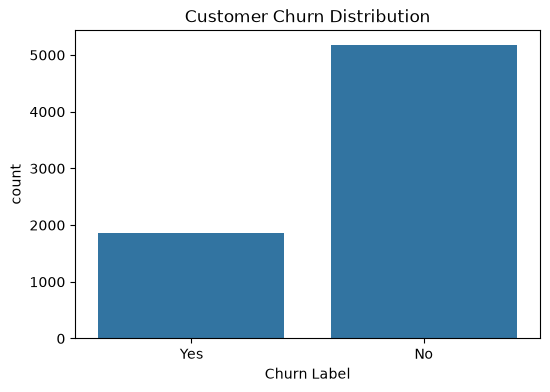

In [4]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Churn Label"
)

plt.title("Customer Churn Distribution")
plt.show()

### Observation

- Most customers have not churned.
- Around one-fourth of customers have churned.
- The dataset has a moderate class imbalance.
- Class imbalance should be considered during model evaluation and preprocessing.
### 💼 Business Insight

The company retains most customers, but approximately one out of every four customers leaves the service. Reducing this churn rate could significantly improve customer retention and revenue.

## 2. Gender Distribution

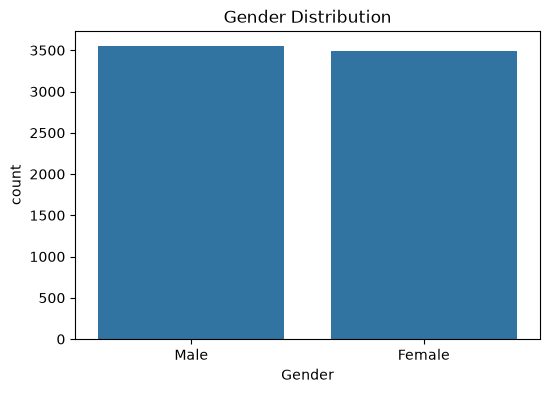

In [5]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Gender"
)

plt.title("Gender Distribution")
plt.show()

### Observation

- The dataset contains an almost equal number of male and female customers.
- There is no significant gender imbalance in the dataset.
### Business Insight

The customer base is well distributed across genders, making the dataset representative. Gender alone is unlikely to dominate churn predictions, but we'll verify this in the next stage.

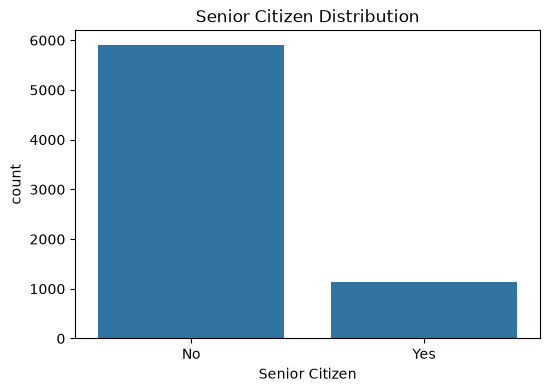

In [6]:
# Senior Citizen
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Senior Citizen"
)

plt.title("Senior Citizen Distribution")
plt.show()

### Observation

- Most customers are not senior citizens.
- Senior citizens represent a relatively small portion of the customer base.
### Business Insight

The company primarily serves non-senior customers. Later, we will analyze whether senior citizens churn at a higher rate despite being fewer in number.

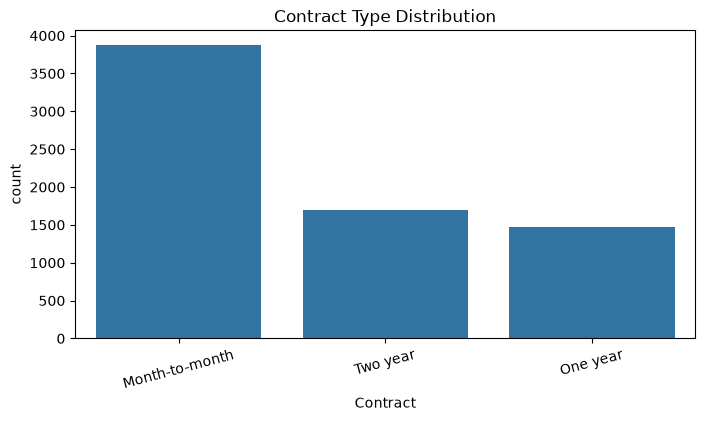

In [7]:
# Contract Type
plt.figure(figsize=(8,4))

sns.countplot(
    data=df,
    x="Contract"
)

plt.title("Contract Type Distribution")
plt.xticks(rotation=15)

plt.show()

### Observation

- Month-to-month contracts are the most common.
- One-year and two-year contracts are comparatively fewer.
### Business Insight

Flexible contracts are more popular. We will later investigate whether customers with month-to-month contracts are more likely to churn.

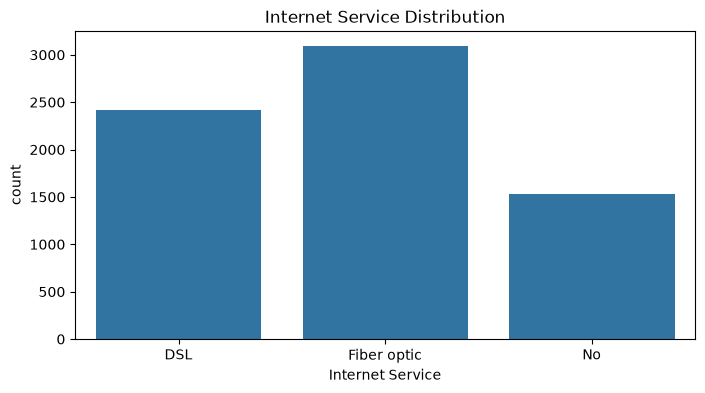

In [8]:
# Internet Service
plt.figure(figsize=(8,4))

sns.countplot(
    data=df,
    x="Internet Service"
)

plt.title("Internet Service Distribution")
plt.show()

### Observation

- Fiber optic is the most commonly used internet service.
- DSL is the second most common service.
- A smaller group of customers does not use internet services.
## Business Insight

Fiber optic has the largest customer base. We will later check whether fiber users experience higher churn compared to DSL users.

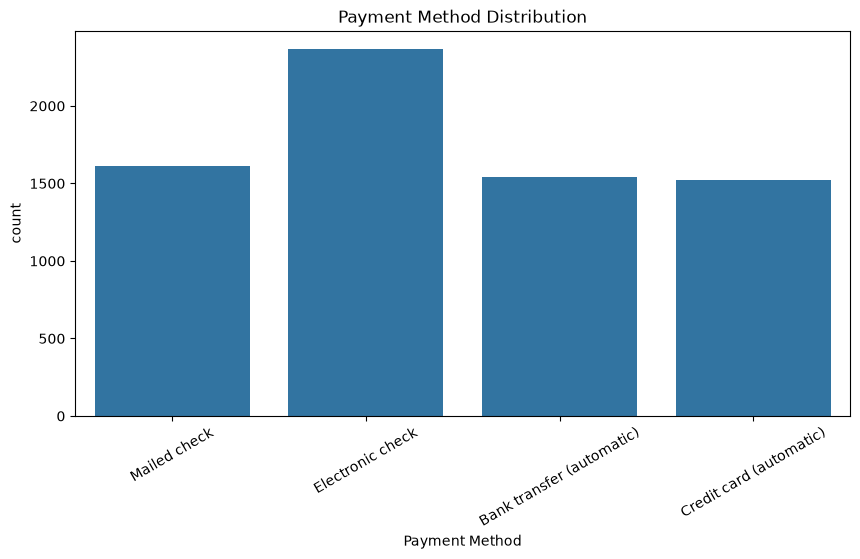

In [9]:
# Payment Method
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="Payment Method"
)

plt.xticks(rotation=30)

plt.title("Payment Method Distribution")

plt.show()

### Observation

- Electronic check is the most frequently used payment method.
- Automatic payment methods are used by fewer customers.
## Business Insight

Electronic check is the preferred payment method among customers. We will investigate whether payment method influences customer churn.

## 📊 Bivariate Analysis

Yahan hum compare karenge:

Feature

↓

Churn

Ye wahi analysis hai jo company ko valuable insights deta hai.

## Gender vs Customer Churn

This analysis helps determine whether customer churn varies across gender groups.

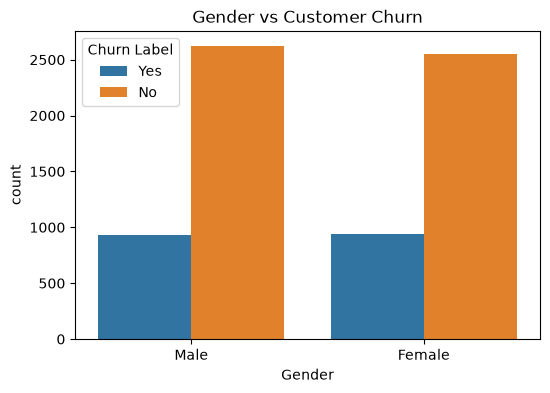

In [10]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x="Gender",
    hue="Churn Label"
)

plt.title("Gender vs Customer Churn")

plt.show()

### Observation

- Male and female customers show a very similar churn distribution.
- Gender does not appear to have a strong influence on customer churn.
### Business Insight

Gender alone is unlikely to be a major factor affecting customer churn. Other customer attributes may have a stronger impact.
### ML Impact

Gender will be retained as a feature, but it is unlikely to be one of the strongest predictors.

In [11]:
pd.crosstab(
    df["Gender"],
    df["Churn Label"],
    normalize="index"
) * 100

Churn Label,No,Yes
Gender,,
Female,73.079128,26.920872
Male,73.839662,26.160338


## Senior Citizen vs Customer Churn

This analysis helps determine whether senior citizens have a different churn behavior compared to non-senior customers.

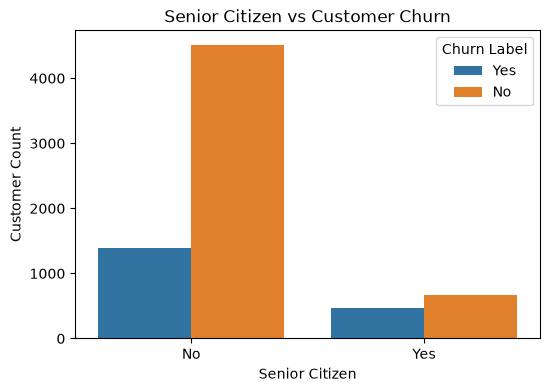

Churn Label,No,Yes
Senior Citizen,,
No,76.393832,23.606168
Yes,58.318739,41.681261


In [4]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Senior Citizen",
    hue="Churn Label"
)

plt.title("Senior Citizen vs Customer Churn")

plt.xlabel("Senior Citizen")
plt.ylabel("Customer Count")

plt.show()
pd.crosstab(
    df["Senior Citizen"],
    df["Churn Label"],
    normalize="index"
) * 100

### Observation

- Senior citizens show a noticeably higher churn rate than non-senior customers.
- Although senior citizens represent a smaller portion of the customer base, they churn more frequently.
### Business Insight

The company should consider targeted retention strategies for senior citizens, such as dedicated support or customized plans.
### ML Impact

Senior Citizen is likely to be an important predictive feature.

## Contract Type vs Customer Churn

This analysis helps identify whether the contract duration influences customer churn.

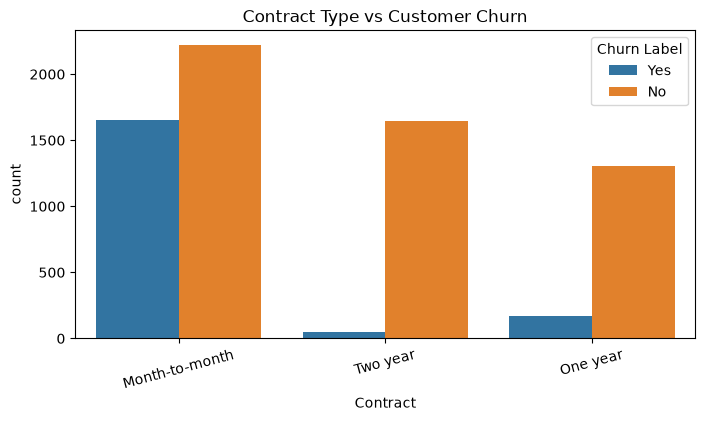

Churn Label,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


In [5]:
plt.figure(figsize=(8,4))

sns.countplot(
    data=df,
    x="Contract",
    hue="Churn Label"
)

plt.title("Contract Type vs Customer Churn")

plt.xticks(rotation=15)

plt.show()
pd.crosstab(
    df["Contract"],
    df["Churn Label"],
    normalize="index"
) * 100

### Observation

- Customers with month-to-month contracts have the highest churn rate.
- Customers with one-year contracts churn much less frequently.
- Customers with two-year contracts rarely churn.
### Business Insight

Long-term contracts significantly improve customer retention. Encouraging customers to switch from month-to-month to longer contracts could reduce churn.
### ML Impact

Contract type is expected to be one of the most influential features in the churn prediction model.

## Internet Service vs Customer Churn

This analysis helps understand whether customers with different internet services have different churn behavior.

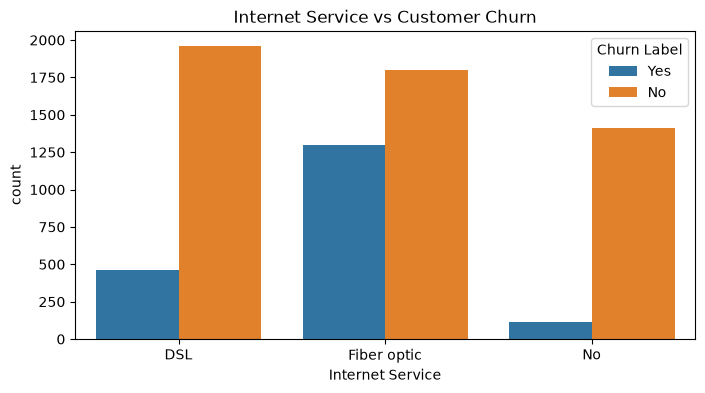

Churn Label,No,Yes
Internet Service,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


In [6]:
plt.figure(figsize=(8,4))

sns.countplot(
    data=df,
    x="Internet Service",
    hue="Churn Label"
)

plt.title("Internet Service vs Customer Churn")

plt.show()
pd.crosstab(
    df["Internet Service"],
    df["Churn Label"],
    normalize="index"
) * 100

### Observation

- Customers using Fiber optic service have the highest churn rate.
- DSL customers churn less frequently.
- Customers without internet service have the lowest churn rate.
### Business Insight

The company should investigate why Fiber optic customers are leaving despite using a premium service. Possible reasons may include pricing, service quality, or customer expectations.
### ML Impact

Internet Service is likely to contribute significantly to churn prediction.

## Payment Method vs Customer Churn

This analysis helps determine whether payment methods are associated with customer churn.

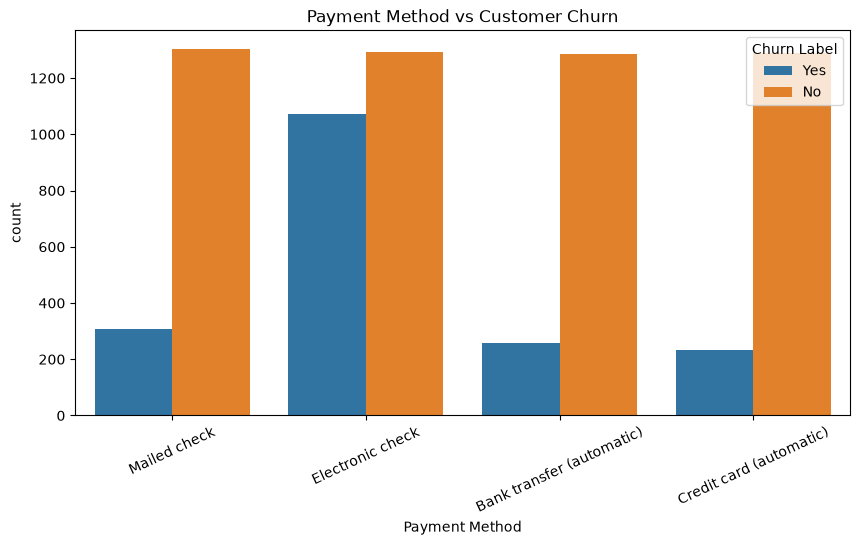

Churn Label,No,Yes
Payment Method,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


In [ ]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="Payment Method",
    hue="Churn Label"
)

plt.title("Payment Method vs Customer Churn")

plt.xticks(rotation=25)

plt.show()
# Percentage table
pd.crosstab(
    df["Payment Method"],
    df["Churn Label"],
    normalize="index"
) * 100

### Observation

- Customers using Electronic Check have a noticeably higher churn rate.
- Automatic payment methods are associated with lower churn.
### Business Insight

Encouraging customers to adopt automatic payment methods may improve customer retention.
### ML Impact

Payment Method is an informative categorical feature and should be retained.

## Monthly Charges vs Customer Churn

This analysis compares the distribution of monthly charges between churned and retained customers.

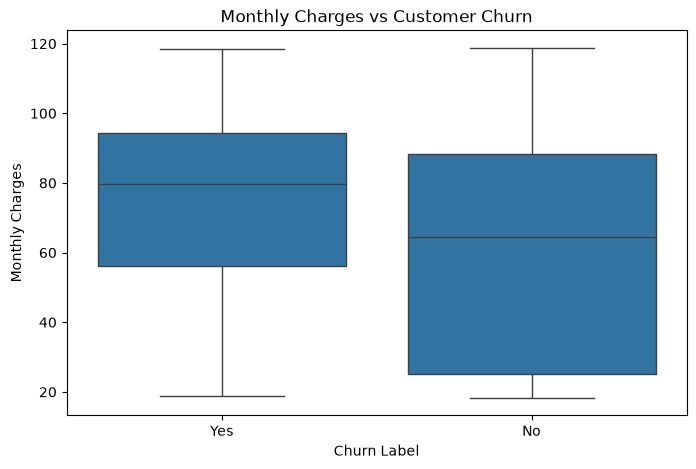

In [8]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Churn Label",
    y="Monthly Charges"
)

plt.title("Monthly Charges vs Customer Churn")

plt.show()

### Observation

- Customers who churn generally have higher monthly charges.
- Higher monthly charges may increase the likelihood of churn.
### Business Insight

Customers with expensive plans may require additional value-added services or discounts to improve retention.
### ML Impact

Monthly Charges is expected to be an important numerical feature.

## Tenure Months vs Customer Churn

This analysis compares customer tenure for churned and retained customers.

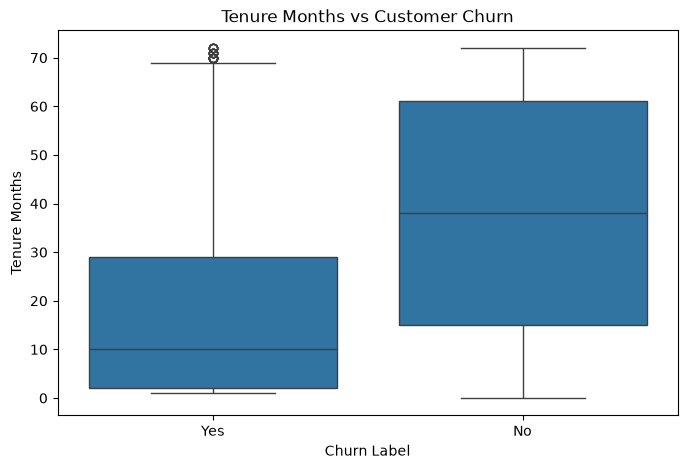

In [9]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Churn Label",
    y="Tenure Months"
)

plt.title("Tenure Months vs Customer Churn")

plt.show()

### Observation

- Customers who churn generally have a much shorter tenure.
- Customers with longer tenure are more likely to remain with the company.
### Business Insight

Customer loyalty increases over time. New customers should receive additional engagement and retention efforts during their initial months.
### ML Impact

Tenure Months is expected to be one of the strongest predictors of customer churn.

# EDA Summary

### Key Findings

- The dataset has a moderate class imbalance.
- Gender does not significantly influence churn.
- Senior citizens have a higher churn tendency.
- Month-to-month contracts have the highest churn rate.
- Fiber optic customers churn more frequently.
- Electronic Check users are more likely to churn.
- Customers with higher monthly charges show higher churn.
- Customers with shorter tenure are much more likely to churn.

### Conclusion

The exploratory data analysis identified several features that are likely to play an important role in predicting customer churn. These findings will guide the preprocessing, feature engineering, and model development phases.

# 📍Phase 2.5 - Advanced Exploratory Data Analysis

In [10]:
df.select_dtypes(include=["int64", "float64"]).columns

Index(['Count', 'Zip Code', 'Latitude', 'Longitude', 'Tenure Months',
       'Monthly Charges', 'Churn Value', 'Churn Score', 'CLTV'],
      dtype='str')

# Correlation Analysis

Correlation analysis helps identify relationships between numerical features.

This analysis is useful for:
- Detecting highly related features
- Understanding feature interactions
- Supporting feature selection

In [11]:
numerical_df = df.select_dtypes(include=["int64", "float64"])

numerical_df.head()

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
0,1,90003,33.964131,-118.272783,2,53.85,1,86,3239
1,1,90005,34.059281,-118.307420,2,70.70,1,67,2701
2,1,90006,34.048013,-118.293953,8,99.65,1,86,5372
3,1,90010,34.062125,-118.315709,28,104.80,1,84,5003
4,1,90015,34.039224,-118.266293,49,103.70,1,89,5340


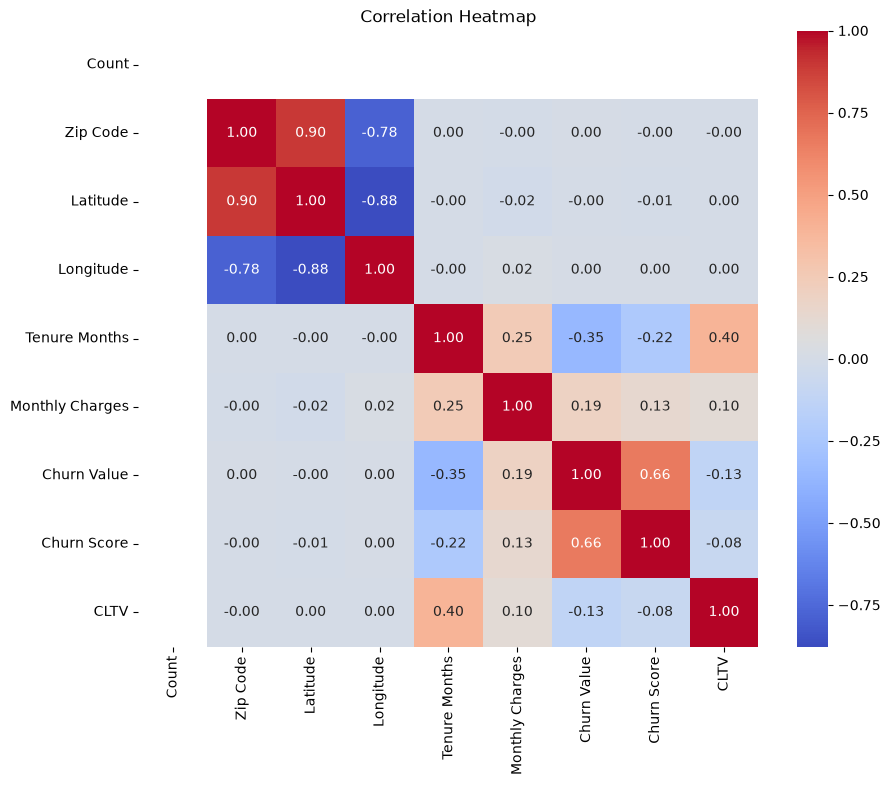

In [12]:
# Heatmap
plt.figure(figsize=(10, 8))

sns.heatmap(
    numerical_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

# WHY are we doing this?

Question:

Why do we check correlation?

Answer:

Detect multicollinearity
Understand relationships
Feature engineering
Feature selection

# Distribution of Monthly Charges

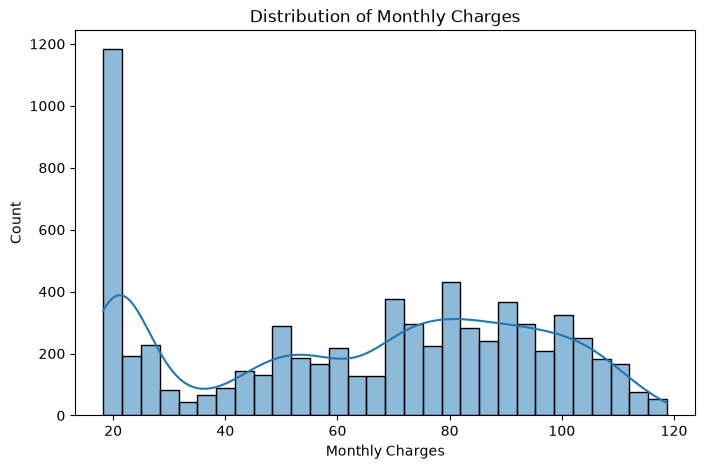

In [13]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="Monthly Charges",
    bins=30,
    kde=True
)

plt.title("Distribution of Monthly Charges")

plt.show()

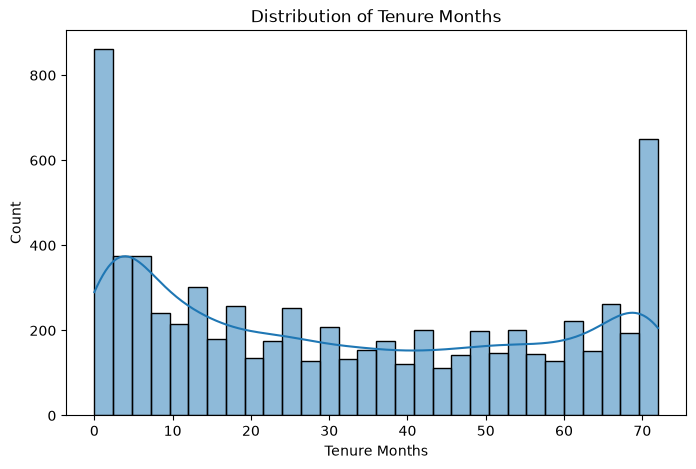

In [14]:
# Tenure months
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="Tenure Months",
    bins=30,
    kde=True
)

plt.title("Distribution of Tenure Months")

plt.show()

# Outlier Detection

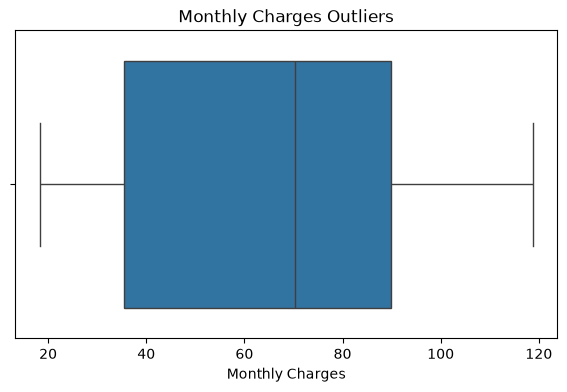

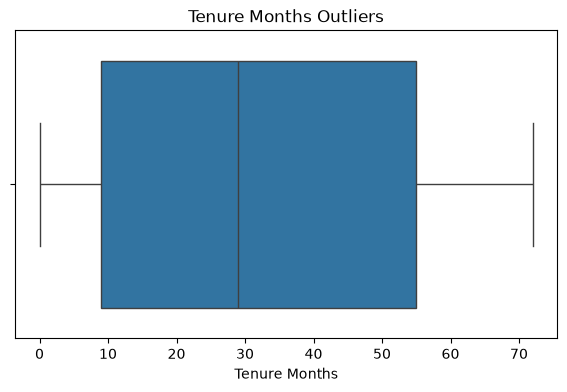

In [21]:
# Monthly Charges
plt.figure(figsize=(7,4))

sns.boxplot(
    x=df["Monthly Charges"]
)

plt.title("Monthly Charges Outliers")

plt.show()

# Tenure
plt.figure(figsize=(7,4))

sns.boxplot(
    x=df["Tenure Months"]
)

plt.title("Tenure Months Outliers")

plt.show()

ValueError: Unable to parse string " " at position 2234

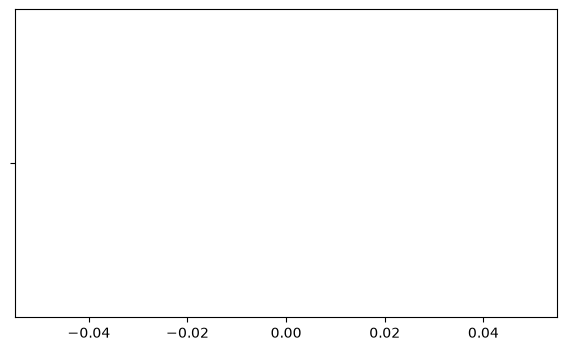

In [23]:
# Total Charges
plt.figure(figsize=(7,4))

sns.boxplot(
    x=df['Total Charges']
)

plt.title("Total Charges Outliers")

plt.show()

# Geographic Analysis

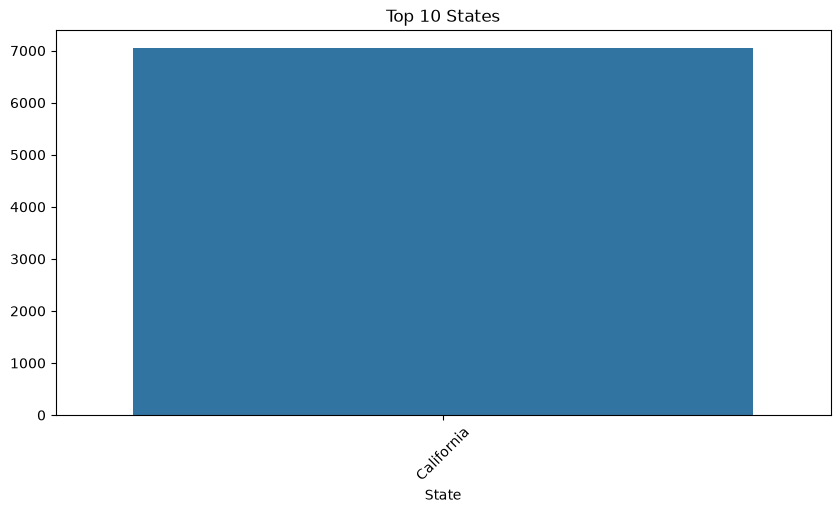

In [24]:
top_states = df["State"].value_counts().head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    x=top_states.index,
    y=top_states.values
)

plt.xticks(rotation=45)

plt.title("Top 10 States")

plt.show()

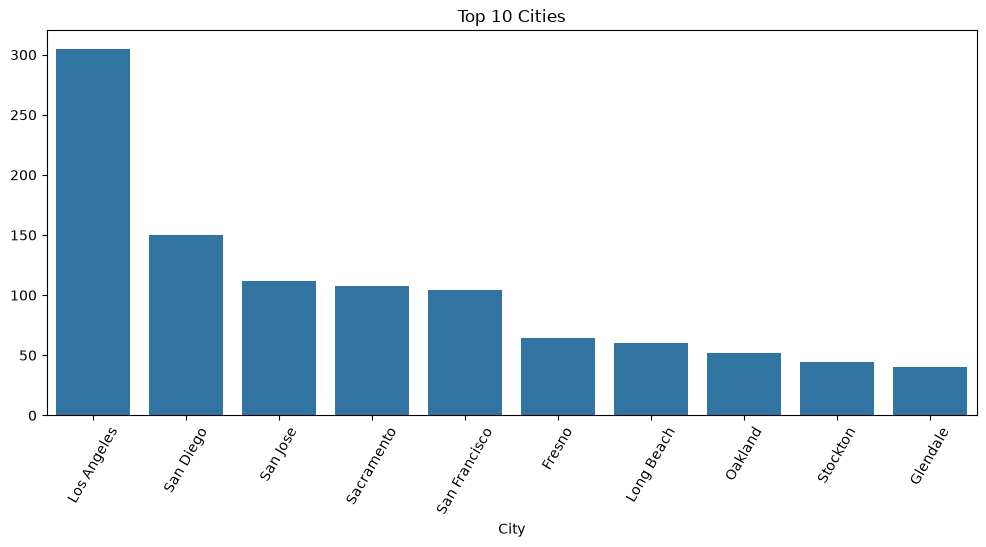

In [25]:
# Same for city
top_city = df["City"].value_counts().head(10)

plt.figure(figsize=(12,5))

sns.barplot(
    x=top_city.index,
    y=top_city.values
)

plt.xticks(rotation=60)

plt.title("Top 10 Cities")

plt.show()

# Relationship Matrix

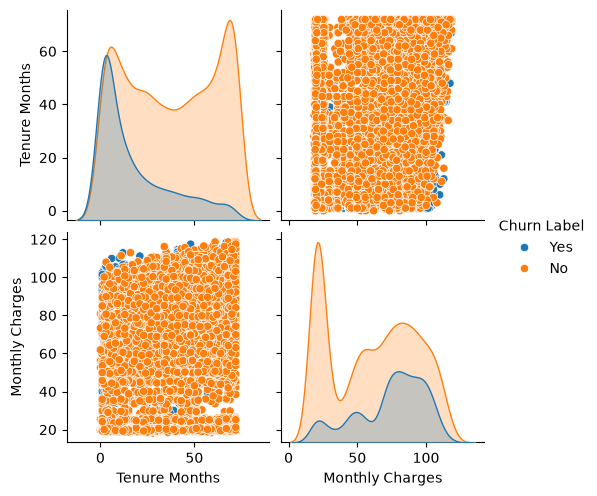

In [26]:
sns.pairplot(
    df[
        [
            "Tenure Months",
            "Monthly Charges",
            "Total Charges",
            "Churn Label"
        ]
    ],
    hue="Churn Label"
)

plt.show()